#EDA

In [1]:
!apt-get install openjdk-8-jdk-headless -qq
!pip install pyspark

In [2]:
# Create Spark session
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("AmazonReviewsEDA") \
    .config("spark.sql.parquet.int96RebaseModeInWrite", "CORRECTED") \
    .config("spark.sql.parquet.int96RebaseModeInRead", "CORRECTED") \
    .config("spark.sql.parquet.outputTimestampType", "TIMESTAMP_MICROS") \
    .getOrCreate()

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Import Spark functions
from pyspark.sql.functions import *

## Load cleaned data

In [5]:
# Load clean parquet
clean_path = "/content/drive/MyDrive/Kpdl1/clean_reviews.parquet"
reviews = spark.read.parquet(clean_path)

print("Number of rows:", reviews.count())
print("Columns:", reviews.columns)

reviews.show(5, truncate=False)
reviews.printSchema()

Number of rows: 43333151
Columns: ['asin', 'parent_asin', 'rating', 'title', 'text', 'timestamp', 'helpful_vote', 'verified_purchase']
+----------+-----------+------+----------------------------+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

## Dataset overview

In [25]:
# Show dataset summary
reviews.agg(
    count("*").alias("num_reviews"),
    countDistinct("parent_asin").alias("num_products"),
    min("timestamp").alias("min_timestamp"),
    max("timestamp").alias("max_timestamp"),
    avg("rating").alias("avg_rating"),
    avg(when(col("verified_purchase") == True, 1).otherwise(0)).alias("verified_ratio")
).show(truncate=False)

+-----------+------------+-------------------+-------------------+-----------------+------------------+
|num_reviews|num_products|min_timestamp      |max_timestamp      |avg_rating       |verified_ratio    |
+-----------+------------+-------------------+-------------------+-----------------+------------------+
|43333151   |1608747     |1996-11-18 16:58:00|2023-09-13 17:26:21|4.099870812533342|0.9242011272155122|
+-----------+------------+-------------------+-------------------+-----------------+------------------+



+------+--------+
|rating|   count|
+------+--------+
|   1.0| 5284875|
|   2.0| 2228775|
|   3.0| 2847076|
|   4.0| 5485457|
|   5.0|27486968|
+------+--------+



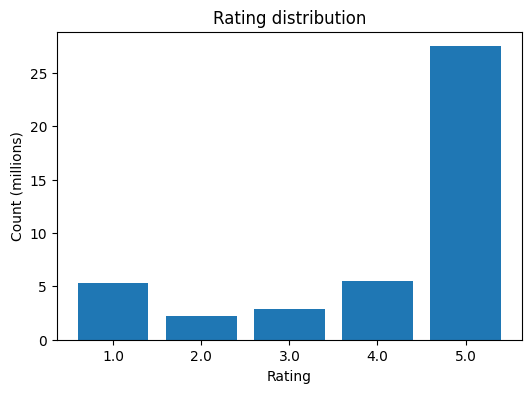

In [20]:
# Show rating distribution
rating_dist = reviews.groupBy("rating").count().orderBy("rating")
rating_dist.show()

# Plot rating distribution
rating_pd = rating_dist.toPandas()
rating_pd["count_million"] = rating_pd["count"] / 1_000_000

plt.figure(figsize=(6,4))
plt.bar(rating_pd["rating"].astype(str), rating_pd["count_million"])
plt.xlabel("Rating")
plt.ylabel("Count (millions)")
plt.title("Rating distribution")
plt.show()

+-----------------+--------+
|verified_purchase|   count|
+-----------------+--------+
|            false| 3284604|
|             true|40048547|
+-----------------+--------+



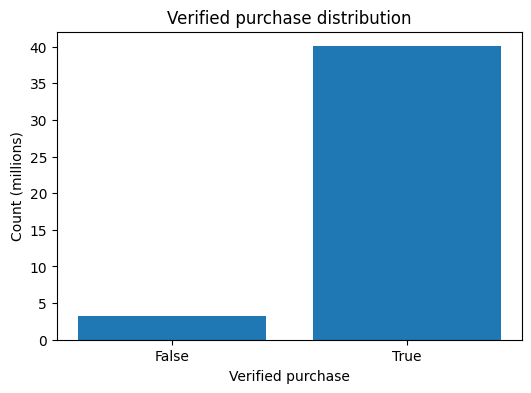

In [21]:
# Show verified purchase distribution
verified_dist = reviews.groupBy("verified_purchase").count().orderBy("verified_purchase")
verified_dist.show()

# Plot verified purchase distribution
verified_pd = verified_dist.toPandas()
verified_pd["count_million"] = verified_pd["count"] / 1_000_000

plt.figure(figsize=(6,4))
plt.bar(verified_pd["verified_purchase"].astype(str), verified_pd["count_million"])
plt.xlabel("Verified purchase")
plt.ylabel("Count (millions)")
plt.title("Verified purchase distribution")
plt.show()

## Review content analysis

+-------+-----------------+
|summary|      text_length|
+-------+-----------------+
|  count|         43333151|
|   mean|228.6632210752456|
| stddev|351.8838320856154|
|    min|                0|
|    max|             4965|
+-------+-----------------+

+-------------+--------+
|length_bucket|   count|
+-------------+--------+
|         0-20| 4866180|
|         >300| 9310390|
|        21-50| 6798132|
|       51-100| 7649346|
|      101-300|14709103|
+-------------+--------+



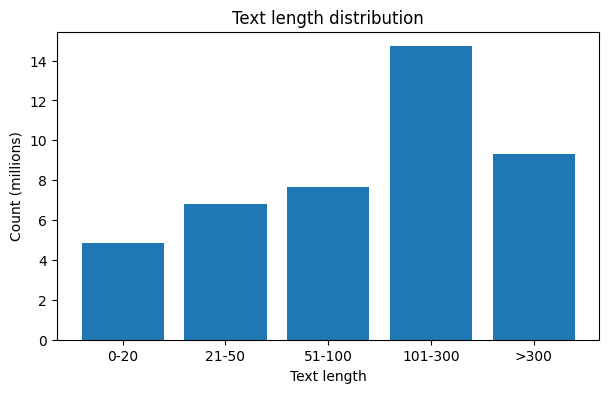

In [18]:
# Create text length
reviews_len = reviews.withColumn(
    "text_length",
    length(trim(col("text")))
)

reviews_len.select("text_length").describe().show()

# Bucket text length
length_dist = reviews_len.select(
    when(col("text_length") <= 20, "0-20")
    .when((col("text_length") <= 50), "21-50")
    .when((col("text_length") <= 100), "51-100")
    .when((col("text_length") <= 300), "101-300")
    .otherwise(">300")
    .alias("length_bucket")
).groupBy("length_bucket").count()

length_dist.show()

# Plot text length distribution
length_pd = length_dist.toPandas()
order = ["0-20", "21-50", "51-100", "101-300", ">300"]

length_pd["length_bucket"] = pd.Categorical(
    length_pd["length_bucket"],
    categories=order,
    ordered=True
)

length_pd = length_pd.sort_values("length_bucket")
length_pd["count_million"] = length_pd["count"] / 1_000_000

plt.figure(figsize=(7,4))
plt.bar(length_pd["length_bucket"], length_pd["count_million"])
plt.xlabel("Text length")
plt.ylabel("Count (millions)")
plt.title("Text length distribution")
plt.show()

##Time-based analysis

+----+-------+
|year|count  |
+----+-------+
|1996|1      |
|1998|8      |
|1999|411    |
|2000|3688   |
|2001|6740   |
|2002|8958   |
|2003|12134  |
|2004|17261  |
|2005|32410  |
|2006|53270  |
|2007|123532 |
|2008|154663 |
|2009|206175 |
|2010|304040 |
|2011|505284 |
|2012|789118 |
|2013|1692981|
|2014|2449056|
|2015|3368530|
|2016|3716024|
+----+-------+
only showing top 20 rows


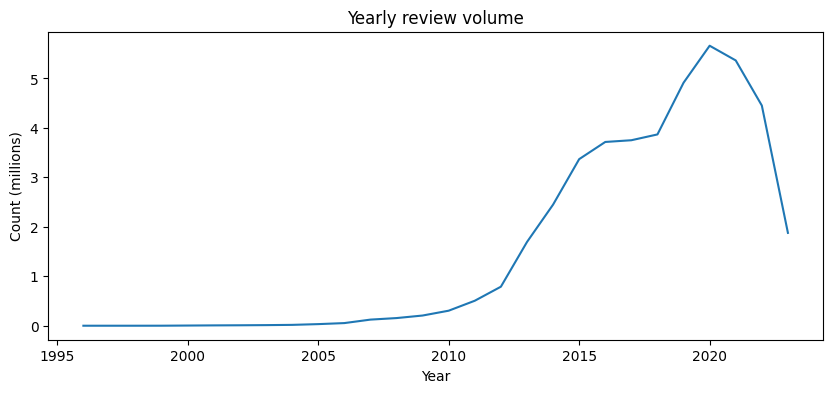

In [22]:
# Create year
reviews_time = reviews.withColumn(
    "year",
    year(col("timestamp"))
).filter(
    col("year").isNotNull()
)

# Show yearly review volume
yearly_reviews = reviews_time.groupBy("year").count().orderBy("year")
yearly_reviews.show(truncate=False)

# Plot yearly review volume
yearly_reviews_pd = yearly_reviews.toPandas()
yearly_reviews_pd["count_million"] = yearly_reviews_pd["count"] / 1_000_000

plt.figure(figsize=(10,4))
plt.plot(yearly_reviews_pd["year"], yearly_reviews_pd["count_million"])
plt.xlabel("Year")
plt.ylabel("Count (millions)")
plt.title("Yearly review volume")
plt.show()

+----+------------+----------------+-------------------+
|year|review_count|low_rating_count|low_rating_rate    |
+----+------------+----------------+-------------------+
|1996|1           |0               |0.0                |
|1998|8           |0               |0.0                |
|1999|411         |51              |0.12408759124087591|
|2000|3688        |466             |0.12635574837310196|
|2001|6740        |1154            |0.1712166172106825 |
|2002|8958        |1835            |0.2048448314355883 |
|2003|12134       |2720            |0.22416350749958794|
|2004|17261       |4684            |0.27136318869126935|
|2005|32410       |8168            |0.2520209811786486 |
|2006|53270       |12176           |0.22857142857142856|
|2007|123532      |20265           |0.16404656283392158|
|2008|154663      |25489           |0.1648034759444728 |
|2009|206175      |36489           |0.17698072026191342|
|2010|304040      |55299           |0.18188067359557952|
|2011|505284      |90938       

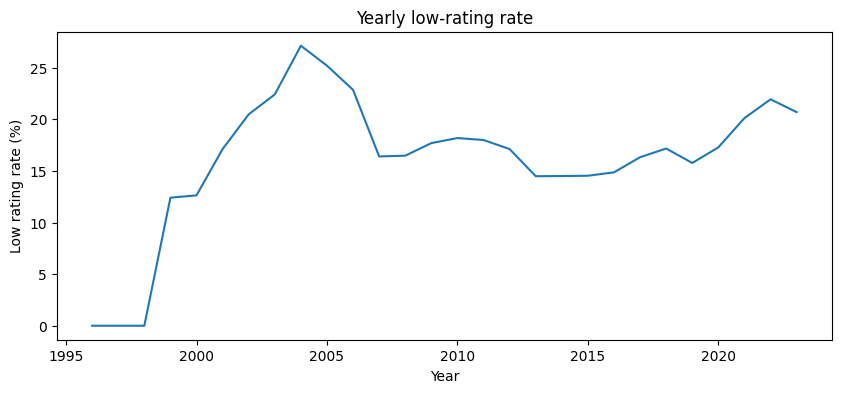

In [24]:
# Show yearly low-rating rate
yearly_low = reviews_time.groupBy("year").agg(
    count("*").alias("review_count"),
    sum(when(col("rating") <= 2, 1).otherwise(0)).alias("low_rating_count")
).withColumn(
    "low_rating_rate",
    col("low_rating_count") / col("review_count")
).orderBy("year")

yearly_low.show(truncate=False)

# Plot yearly low-rating rate
yearly_low_pd = yearly_low.toPandas()
yearly_low_pd["low_rating_pct"] = yearly_low_pd["low_rating_rate"] * 100

plt.figure(figsize=(10,4))
plt.plot(yearly_low_pd["year"], yearly_low_pd["low_rating_pct"])
plt.xlabel("Year")
plt.ylabel("Low rating rate (%)")
plt.title("Yearly low-rating rate")
plt.show()

In [15]:
# Build product-level stats
product_stats = reviews.groupBy("parent_asin").agg(
    count("*").alias("review_count"),
    avg("rating").alias("avg_rating"),
    sum(when(col("rating") <= 2, 1).otherwise(0)).alias("low_rating_count")
).withColumn(
    "low_rating_rate",
    col("low_rating_count") / col("review_count")
)

In [17]:
# Show risky products
product_stats.filter(col("review_count") >= 20) \
    .orderBy(col("low_rating_rate").desc(), col("review_count").desc()) \
    .show(20, truncate=False)

+-----------+------------+------------------+----------------+------------------+
|parent_asin|review_count|avg_rating        |low_rating_count|low_rating_rate   |
+-----------+------------+------------------+----------------+------------------+
|B0BBQR8C68 |44          |1.0227272727272727|44              |1.0               |
|B0BPGKHL14 |33          |1.0606060606060606|33              |1.0               |
|B08JWGFJK2 |26          |1.1153846153846154|26              |1.0               |
|B08P33Y2Q5 |25          |1.04              |25              |1.0               |
|B0824ZD551 |23          |1.0               |23              |1.0               |
|B075DB96PZ |21          |1.0               |21              |1.0               |
|B0788HNVV4 |320         |1.059375          |317             |0.990625          |
|B0778J7H4M |61          |1.0491803278688525|60              |0.9836065573770492|
|B076T16SMX |42          |1.0952380952380953|41              |0.9761904761904762|
|B07922Q1YJ |41 